In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import mne
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm

from src.data import add_metadata_features

In [3]:
all_epochs = list(Path("outputs/epochs_preprocessed").glob("*_epo.fif"))
all_epochs

[PosixPath('outputs/epochs_preprocessed/EC279_epo.fif'),
 PosixPath('outputs/epochs_preprocessed/EC243_epo.fif'),
 PosixPath('outputs/epochs_preprocessed/EC260_epo.fif'),
 PosixPath('outputs/epochs_preprocessed/EC253_epo.fif'),
 PosixPath('outputs/epochs_preprocessed/EC270_epo.fif'),
 PosixPath('outputs/epochs_preprocessed/EC278_epo.fif'),
 PosixPath('outputs/epochs_preprocessed/EC248_epo.fif'),
 PosixPath('outputs/epochs_preprocessed/EC282_epo.fif'),
 PosixPath('outputs/epochs_preprocessed/EC287_epo.fif'),
 PosixPath('outputs/epochs_preprocessed/EC250_epo.fif')]

In [4]:
all_metadata = pd.concat({ep.name.split("_")[0]: mne.read_epochs(str(ep)).metadata for ep in all_epochs},
                         names=["subject"])

Reading /userdata/jgauthier/projects/barakeet/outputs/epochs_preprocessed/EC279_epo.fif ...
Isotrak not found
    Found the data of interest:
        t =    -400.00 ...    2990.00 ms
        0 CTF compensation matrices available
Adding metadata with 72 columns
864 matching events found
No baseline correction applied
0 projection items activated
Reading /userdata/jgauthier/projects/barakeet/outputs/epochs_preprocessed/EC243_epo.fif ...
Isotrak not found
    Found the data of interest:
        t =    -400.00 ...    2990.00 ms
        0 CTF compensation matrices available
Adding metadata with 72 columns
864 matching events found
No baseline correction applied
0 projection items activated
Reading /userdata/jgauthier/projects/barakeet/outputs/epochs_preprocessed/EC260_epo.fif ...
Isotrak not found
    Found the data of interest:
        t =    -400.00 ...    2990.00 ms
        0 CTF compensation matrices available
Adding metadata with 72 columns
864 matching events found
No baseline correct

In [5]:
# g = sns.displot(data=all_metadata.reset_index(), row="subject",
#                 x="slider.response", height=1.5, aspect=2.5,
#                 bins=10, discrete=True,
#                 facet_kws={"sharex": False, "sharey": False})
# for ax in g.axes.flat:
#     ax.set_xticks(list(range(1, 11)))

In [5]:
extdf = add_metadata_features(all_metadata.reset_index())
extdf["correct"] = extdf.behavior_categorical_forced == extdf.lexical_evidence_cue

subject_order = extdf.groupby("subject").correct.mean().sort_values(ascending=False).index
extdf

,subject,level_1,wav_file,stim_number,word_end,non_word,phoneme_pair,morph_n,base,file_format,...,label_behavior,follows_acoustics,ignores_both_cues,label_lexical_behavior,label_acoustic_emoji,label_behavior_emoji,feat_behavior_acoustic,feat_behavior_lexical,feat_behavior_mismatch_left_right,correct
0,EC279,0,stimuli/2_mountains_bm_002.wav,2.0,mountains,bountains,bm,2.0,2_mountains_bm_002,wav,...,m,False,False,LmBm,Ab,Bm,-1.0,1.0,1.0,True
1,EC279,1,stimuli/11_necessary_dn_004.wav,11.0,necessary,decessary,dn,4.0,11_necessary_dn_004,wav,...,d,True,False,LnBd,Ad,Bd,1.0,-1.0,-1.0,False
2,EC279,2,stimuli/35_penecillin_pb_011.wav,35.0,penecillin,benecillin,pb,11.0,35_penecillin_pb_011,wav,...,p,False,False,LpBp,Ab,Bp,-1.0,1.0,1.0,True
3,EC279,3,stimuli/35_beneficial_pb_008.wav,35.0,beneficial,peneficial,pb,8.0,35_beneficial_pb_008,wav,...,p,True,False,LbBp,Ap,Bp,1.0,-1.0,-1.0,False
4,EC279,4,stimuli/11_desolate_dn_006.wav,11.0,desolate,nesolate,dn,6.0,11_desolate_dn_006,wav,...,n,True,False,LdBn,An,Bn,1.0,-1.0,-1.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7771,EC250,859,stimuli/2_mountains_bm_001.wav,2.0,mountains,bountains,bm,1.0,2_mountains_bm_001,wav,...,b,True,False,LmBb,Ab,Bb,1.0,-1.0,-1.0,False
7772,EC250,860,stimuli/11_desolate_dn_007.wav,11.0,desolate,nesolate,dn,7.0,11_desolate_dn_007,wav,...,n,True,False,LdBn,An,Bn,1.0,-1.0,-1.0,False
7773,EC250,861,stimuli/2_mountains_bm_006.wav,2.0,mountains,bountains,bm,6.0,2_mountains_bm_006,wav,...,m,True,False,LmBm,Am,Bm,1.0,1.0,0.0,True
7774,EC250,862,stimuli/2_bountiful_bm_004.wav,2.0,bountiful,mountiful,bm,4.0,2_bountiful_bm_004,wav,...,m,True,False,LbBm,Am,Bm,1.0,-1.0,-1.0,False


In [9]:
extdf[~extdf.resampled.isin((1,2,5,6))].groupby("phoneme_pair").correct.mean()

phoneme_pair
bm    0.524306
dn    0.574074
pb    0.613426
Name: correct, dtype: float64

In [10]:
extdf[extdf.resampled.isin((1,2,5,6))].groupby("phoneme_pair").correct.mean()

phoneme_pair
bm    0.530671
dn    0.517361
pb    0.619792
Name: correct, dtype: float64

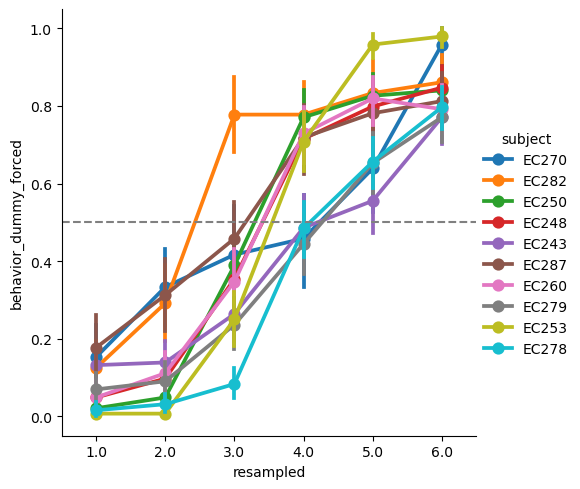

In [7]:
g = sns.catplot(data=extdf, x="resampled", y="behavior_dummy_forced", hue="subject", hue_order=subject_order, kind="point")
for ax in g.axes.flat:
    ax.axhline(0.5, color="gray", linestyle="--")

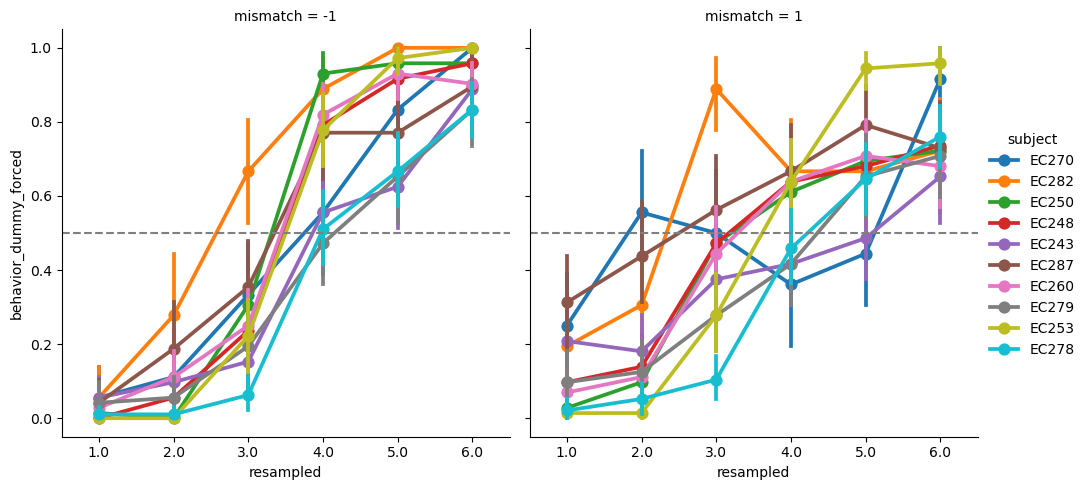

In [8]:
g = sns.catplot(data=extdf, x="resampled", y="behavior_dummy_forced", hue="subject", hue_order=subject_order, col="mismatch", kind="point")
for ax in g.axes.flat:
    ax.axhline(0.5, color="gray", linestyle="--")

In [9]:
extdf.query("subject == 'EC270' and mismatch == 1 and phoneme_pair == 'dn'")[["linear_acoustic_cue", "behavior_linear", "label_acoustic", "label_lexical", "label_behavior"]].sample(10).sort_values('linear_acoustic_cue')

,linear_acoustic_cue,behavior_linear,label_acoustic,label_lexical,label_behavior
3510,-1.0,0.474537,d,n,n
3797,-1.0,0.969907,d,n,n
3616,-1.0,0.946759,d,n,n
3495,-0.6,0.495370,d,n,n
3791,-0.6,0.905093,d,n,n
3631,-0.2,0.641204,d,n,n
3793,0.2,1.000000,n,d,n
3528,0.6,0.560185,n,d,n
3701,0.6,-0.592593,n,d,d
3561,1.0,0.321759,n,d,n


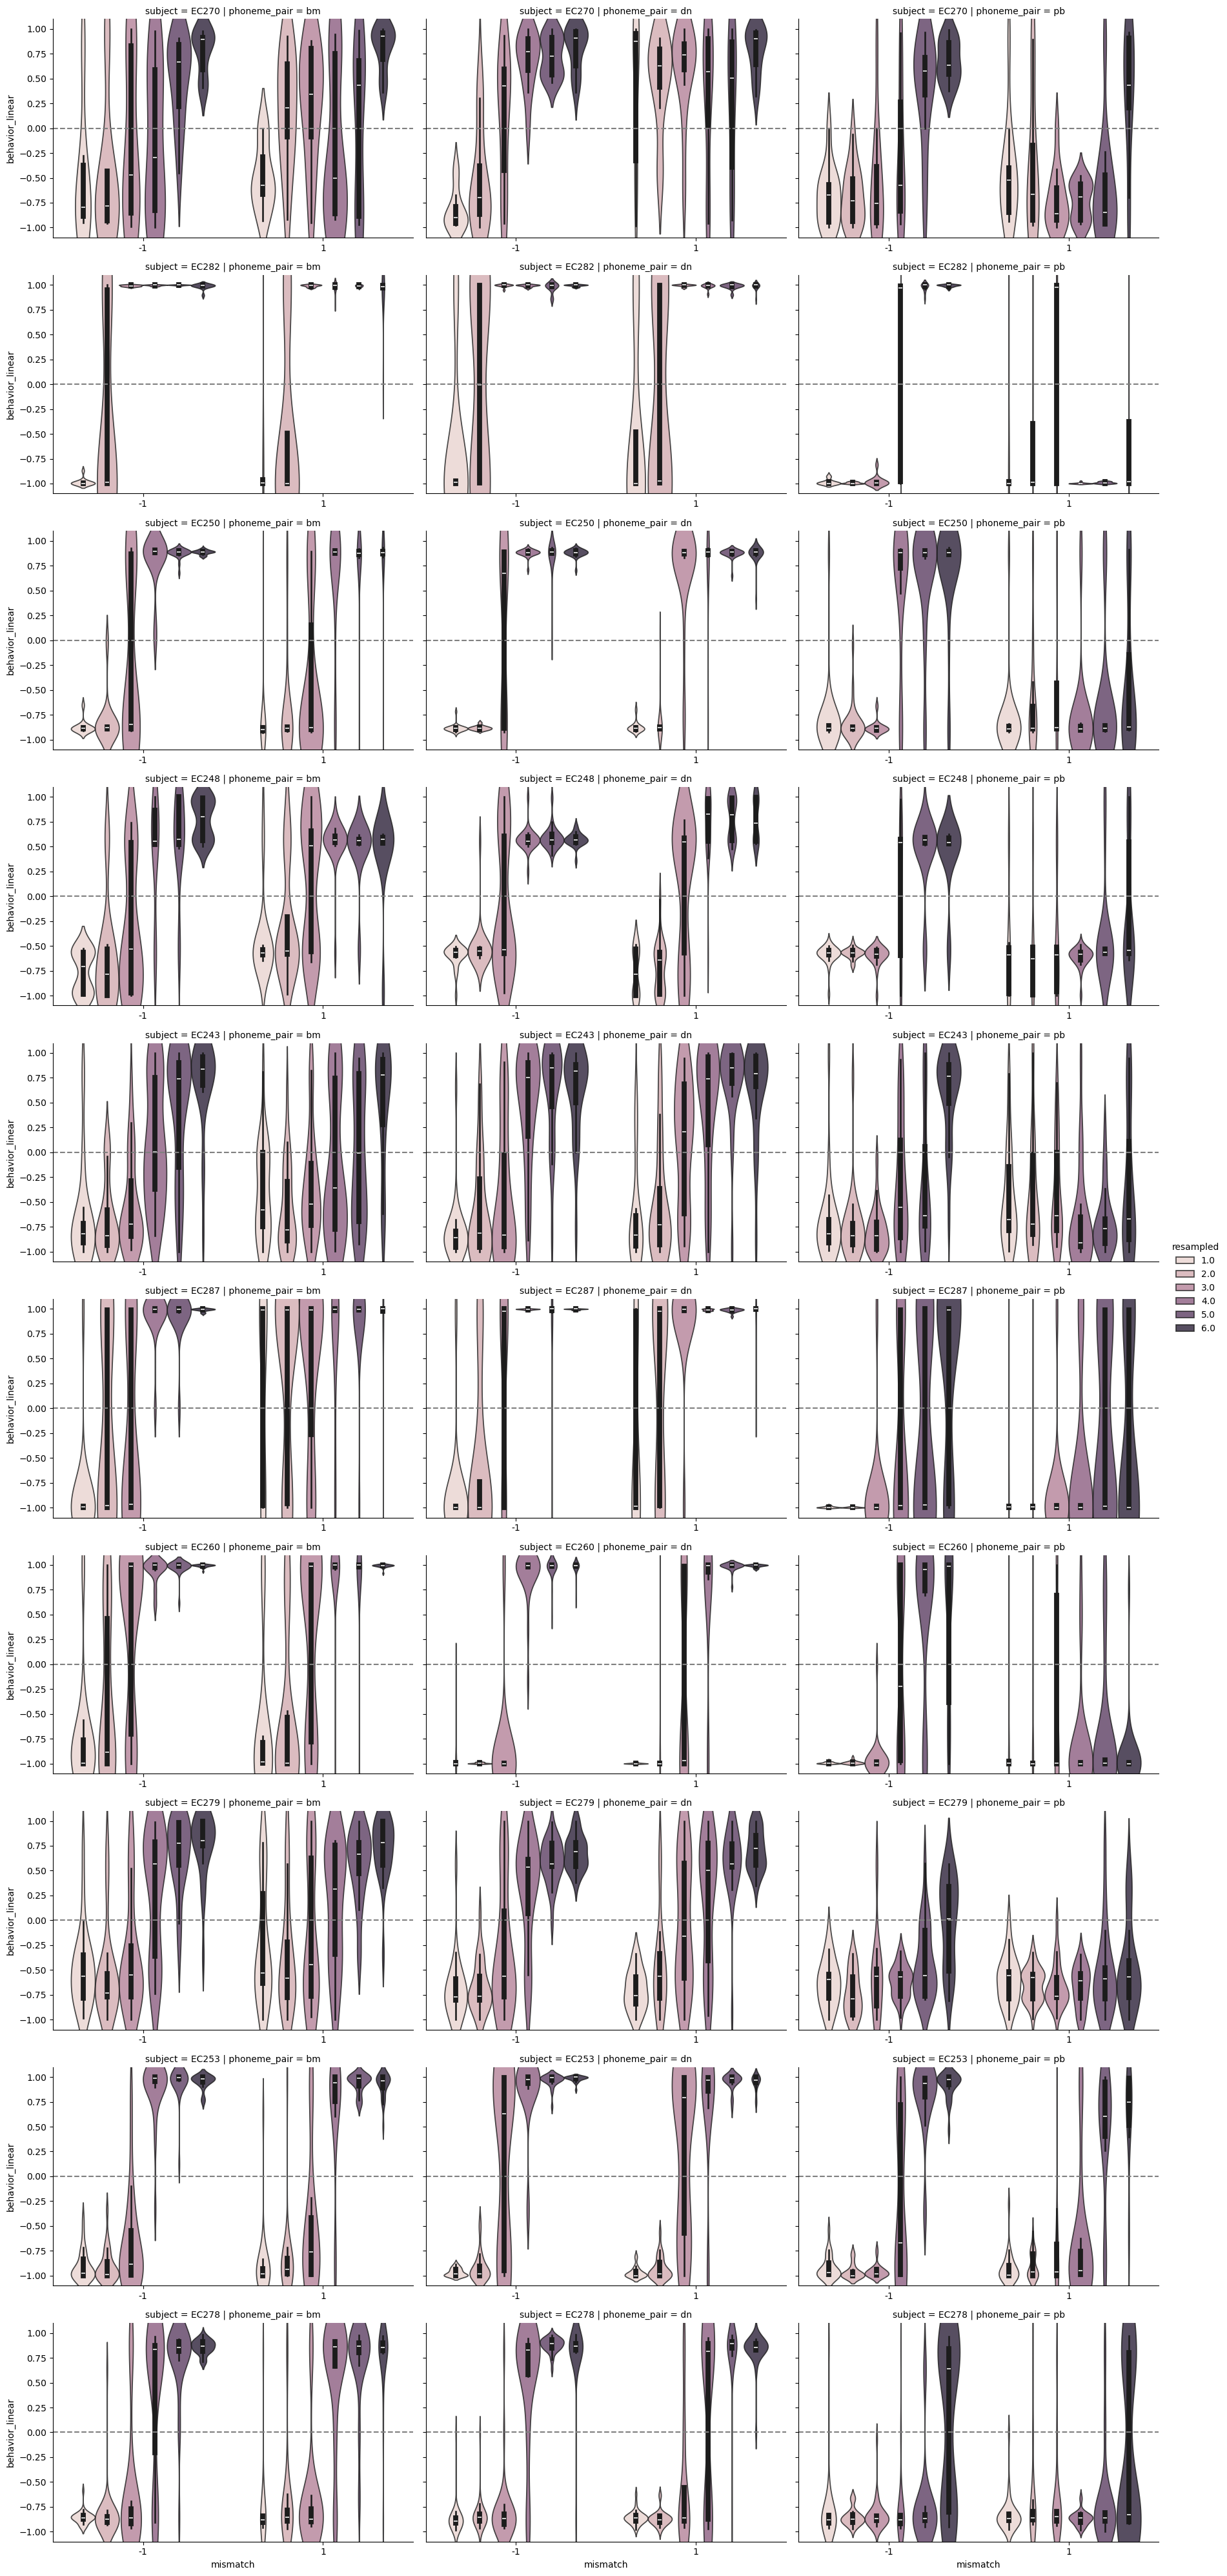

In [10]:
g = sns.catplot(data=extdf.assign(mismatch=extdf.mismatch.astype(str)),
                x="mismatch", order=[-1, 1], y="behavior_linear", hue="resampled",
                row="subject", row_order=subject_order, col="phoneme_pair",
                kind="violin", sharex=False, alpha=0.8, height=4, aspect=1.5)
for ax in g.axes.flat:
    ax.axhline(0.0, color="gray", linestyle="--")
    ax.set_ylim((-1.1, 1.1))

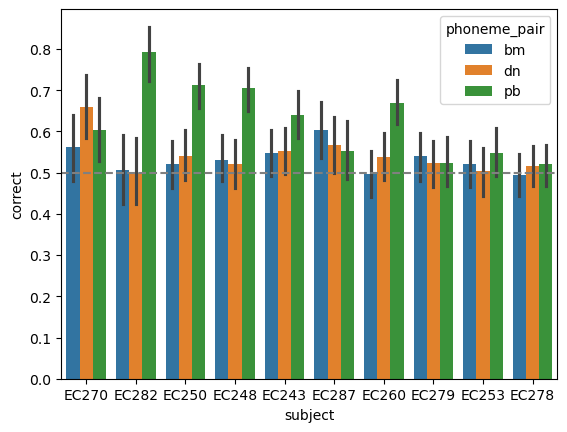

In [11]:
# overall accuracy
ax = sns.barplot(data=extdf, x="subject", hue="phoneme_pair", y="correct", order=subject_order)
ax.axhline(0.5, color="gray", linestyle="--")

In [12]:
extdf.groupby("subject").correct.mean().sort_values(ascending=False)

subject
EC270    0.608796
EC282    0.599537
EC250    0.591435
EC248    0.585648
EC243    0.579861
EC287    0.574653
EC260    0.568287
EC279    0.530093
EC253    0.524306
EC278    0.510417
Name: correct, dtype: float64

In [13]:
# sns.catplot(data=extdf.groupby(["subject", "resampled", "mismatch", "phoneme_pair"]).follows_acoustics.mean().reset_index(),
#             x="subject", hue="resampled", y="follows_acoustics", kind="bar", row="mismatch", col="phoneme_pair")

In [14]:
# sns.catplot(data=extdf.groupby(["subject", "belief_update"]).follows_acoustics.mean().reset_index(),
#             x="subject", hue="belief_update", y="follows_acoustics", kind="bar")

Text(0.5, 1.0, 'Proportion of behavioral responses\nwhich ignore consistent acoustic+lexical cues')

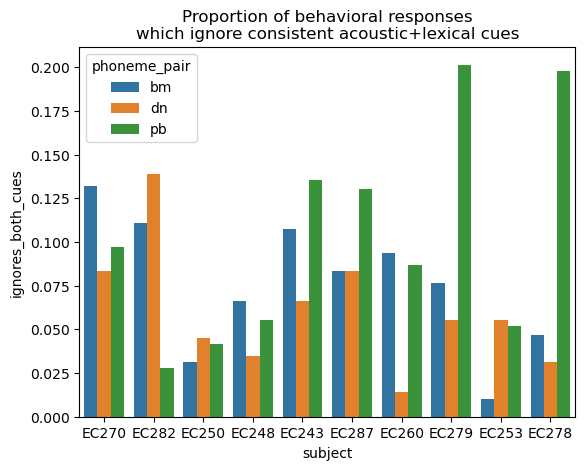

In [15]:
ax = sns.barplot(data=extdf.groupby(["subject", "phoneme_pair"]).ignores_both_cues.mean().reset_index(),
                 x="subject", hue="phoneme_pair", y="ignores_both_cues", order=subject_order)
ax.set_title("Proportion of behavioral responses\nwhich ignore consistent acoustic+lexical cues")

In [16]:
extdf.ignores_both_cues.mean()

0.07741769547325103

## Sequence effects

In [17]:
extdf["trial_idx"] = extdf.groupby("subject").cumcount()

<Axes: xlabel='trial_idx'>

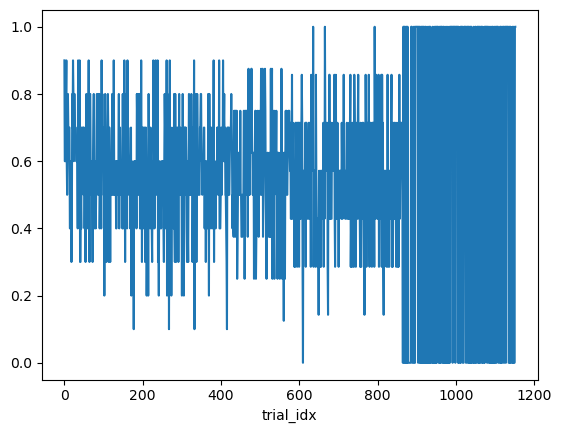

In [18]:
extdf.groupby("trial_idx").correct.mean().plot()

<Axes: xlabel='trial_idx'>

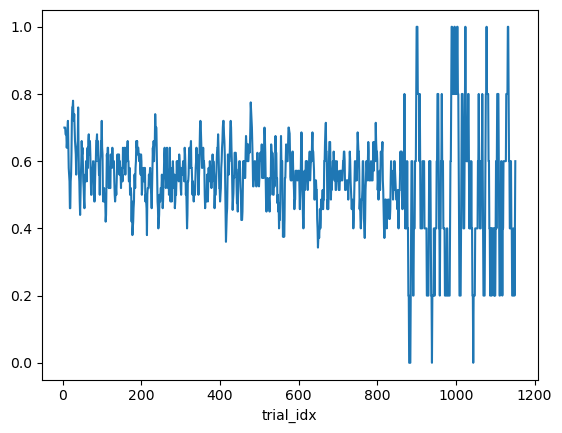

In [19]:
extdf.groupby("trial_idx").correct.mean().rolling(5).mean().plot()

In [20]:
extdf[["slider_reorient", "acoustic_slider", "slider.response", "behavior_sign"]]

,slider_reorient,acoustic_slider,slider.response,behavior_sign
0,7.989063,7.989063,3.010937,-1
1,3.995312,3.995312,3.995312,1
2,2.982813,8.017188,8.017188,-1
3,2.054688,8.945312,2.054688,1
4,9.964844,9.964844,1.035156,-1
...,...,...,...,...
7771,1.425000,1.425000,1.425000,1
7772,9.412500,9.412500,9.412500,1
7773,9.625000,9.625000,9.625000,1
7774,9.537500,9.537500,1.462500,-1


In [21]:
extdf[extdf.subject == "EC278"]

,subject,level_1,wav_file,stim_number,word_end,non_word,phoneme_pair,morph_n,base,file_format,...,follows_acoustics,ignores_both_cues,label_lexical_behavior,label_acoustic_emoji,label_behavior_emoji,feat_behavior_acoustic,feat_behavior_lexical,feat_behavior_mismatch_left_right,correct,trial_idx
3888,EC278,0,stimuli/35_beneficial_pb_009.wav,35.0,beneficial,peneficial,pb,9.0,35_beneficial_pb_009,wav,...,True,False,LbBb,Ab,Bb,1.0,1.0,0.0,True,0
3889,EC278,1,stimuli/11_desolate_dn_005.wav,11.0,desolate,nesolate,dn,5.0,11_desolate_dn_005,wav,...,False,False,LdBd,An,Bd,-1.0,1.0,1.0,True,1
3890,EC278,2,stimuli/2_mountains_bm_001.wav,2.0,mountains,bountains,bm,1.0,2_mountains_bm_001,wav,...,True,False,LmBb,Ab,Bb,1.0,-1.0,-1.0,False,2
3891,EC278,3,stimuli/11_desolate_dn_006.wav,11.0,desolate,nesolate,dn,6.0,11_desolate_dn_006,wav,...,False,False,LdBd,An,Bd,-1.0,1.0,1.0,True,3
3892,EC278,4,stimuli/2_bountiful_bm_001.wav,2.0,bountiful,mountiful,bm,1.0,2_bountiful_bm_001,wav,...,True,False,LbBb,Ab,Bb,1.0,1.0,-0.0,True,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5035,EC278,1147,stimuli/11_necessary_dn_006.wav,11.0,necessary,decessary,dn,6.0,11_necessary_dn_006,wav,...,True,False,LnBn,An,Bn,1.0,1.0,0.0,True,1147
5036,EC278,1148,stimuli/2_mountains_bm_002.wav,2.0,mountains,bountains,bm,2.0,2_mountains_bm_002,wav,...,True,False,LmBb,Ab,Bb,1.0,-1.0,-1.0,False,1148
5037,EC278,1149,stimuli/2_bountiful_bm_006.wav,2.0,bountiful,mountiful,bm,6.0,2_bountiful_bm_006,wav,...,True,False,LbBm,Am,Bm,1.0,-1.0,-1.0,False,1149
5038,EC278,1150,stimuli/2_mountains_bm_004.wav,2.0,mountains,bountains,bm,4.0,2_mountains_bm_004,wav,...,True,False,LmBm,Am,Bm,1.0,1.0,0.0,True,1150


Text(0, 0.5, '100-trial rolling accuracy')

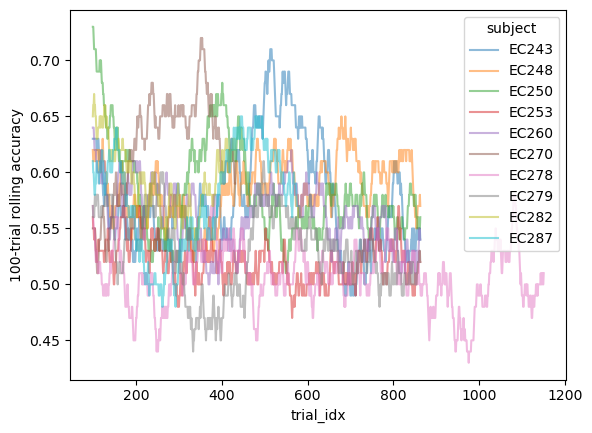

In [22]:
ax = extdf.sort_values("trial_idx").reset_index().set_index("trial_idx").groupby("subject").correct.rolling(100).mean().unstack("subject").plot(alpha=0.5)
ax.set_ylabel("100-trial rolling accuracy")

In [23]:
extdf[extdf.subject == "EC270"]

,subject,level_1,wav_file,stim_number,word_end,non_word,phoneme_pair,morph_n,base,file_format,...,follows_acoustics,ignores_both_cues,label_lexical_behavior,label_acoustic_emoji,label_behavior_emoji,feat_behavior_acoustic,feat_behavior_lexical,feat_behavior_mismatch_left_right,correct,trial_idx
3456,EC270,0,stimuli/11_desolate_dn_002.wav,11.0,desolate,nesolate,dn,2.0,11_desolate_dn_002,wav,...,True,False,LdBd,Ad,Bd,1.0,1.0,-0.0,True,0
3457,EC270,1,stimuli/35_penecillin_pb_008.wav,35.0,penecillin,benecillin,pb,8.0,35_penecillin_pb_008,wav,...,False,True,LpB~,Ap,B~,-0.0,-0.0,0.0,False,1
3458,EC270,2,stimuli/11_necessary_dn_002.wav,11.0,necessary,decessary,dn,2.0,11_necessary_dn_002,wav,...,True,False,LnBd,Ad,Bd,1.0,-1.0,-1.0,False,2
3459,EC270,3,stimuli/11_desolate_dn_006.wav,11.0,desolate,nesolate,dn,6.0,11_desolate_dn_006,wav,...,True,False,LdBn,An,Bn,1.0,-1.0,-1.0,False,3
3460,EC270,4,stimuli/11_necessary_dn_004.wav,11.0,necessary,decessary,dn,4.0,11_necessary_dn_004,wav,...,False,False,LnBn,Ad,Bn,-1.0,1.0,1.0,True,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3883,EC270,427,stimuli/2_mountains_bm_005.wav,2.0,mountains,bountains,bm,5.0,2_mountains_bm_005,wav,...,True,False,LmBm,Am,Bm,1.0,1.0,0.0,True,427
3884,EC270,428,stimuli/2_bountiful_bm_001.wav,2.0,bountiful,mountiful,bm,1.0,2_bountiful_bm_001,wav,...,True,False,LbBb,Ab,Bb,1.0,1.0,-0.0,True,428
3885,EC270,429,stimuli/11_desolate_dn_005.wav,11.0,desolate,nesolate,dn,5.0,11_desolate_dn_005,wav,...,True,False,LdBn,An,Bn,1.0,-1.0,-1.0,False,429
3886,EC270,430,stimuli/11_desolate_dn_007.wav,11.0,desolate,nesolate,dn,7.0,11_desolate_dn_007,wav,...,True,False,LdBn,An,Bn,1.0,-1.0,-1.0,False,430


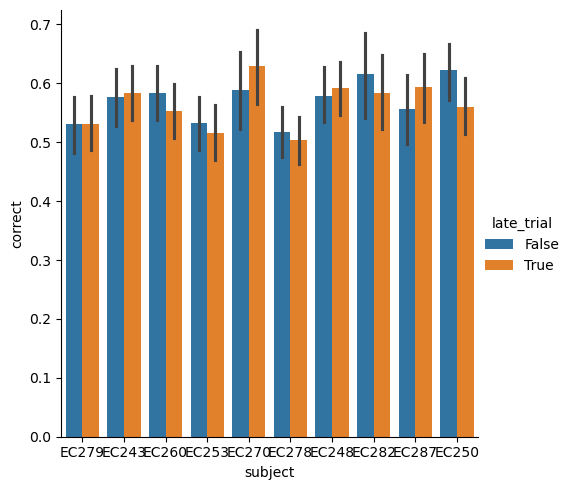

In [24]:
extdf["late_trial"] = extdf.groupby("subject").trial_idx.transform(lambda x: x > x.max() / 2)
sns.catplot(data=extdf, x="subject", y="correct", hue="late_trial", kind="bar")

In [25]:
seq_test = extdf.groupby(["late_trial", "subject", "phoneme_pair"]).correct.mean()
seq_diff = seq_test.loc[True] - seq_test.loc[False]
seq_diff

subject  phoneme_pair
EC243    bm              0.138889
         dn             -0.104167
         pb             -0.013889
EC248    bm              0.062500
         dn              0.000000
         pb             -0.020833
EC250    bm             -0.083333
         dn             -0.027778
         pb             -0.076389
EC253    bm              0.013889
         dn             -0.006944
         pb             -0.055556
EC260    bm             -0.048611
         dn             -0.020833
         pb             -0.020833
EC270    bm             -0.097222
         dn              0.125000
         pb              0.097222
EC278    bm              0.000000
         dn             -0.020833
         pb             -0.020833
EC279    bm             -0.097222
         dn              0.048611
         pb              0.048611
EC282    bm             -0.041667
         dn              0.027778
         pb             -0.083333
EC287    bm              0.104167
         dn              0

Text(0.5, 1.0, 'No sequence effects')

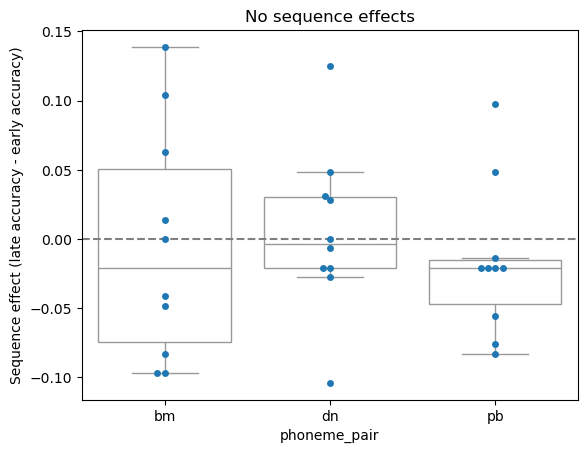

In [26]:
ax = sns.swarmplot(data=seq_diff.reset_index(), x="phoneme_pair", y="correct")
sns.boxplot(data=seq_diff.reset_index(), x="phoneme_pair", y="correct", color="white", showfliers=False, ax=ax)
ax.axhline(0, color="gray", linestyle="--")
ax.set_ylabel("Sequence effect (late accuracy - early accuracy)")
ax.set_title("No sequence effects")

Text(0.5, 1.0, 'No sequence effects')

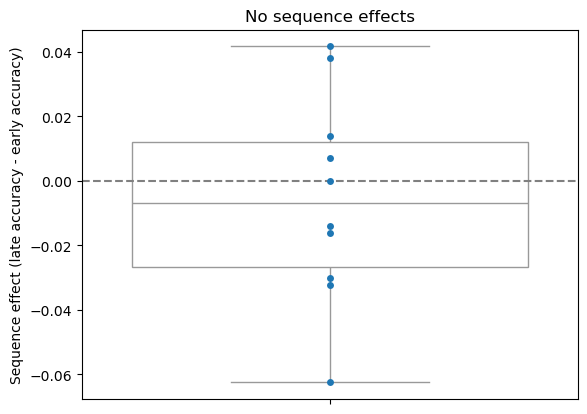

In [27]:
ax = sns.swarmplot(data=seq_diff.groupby("subject").mean().reset_index(), y="correct")
sns.boxplot(data=seq_diff.groupby("subject").mean().reset_index(), y="correct", color="white", showfliers=False, ax=ax)
ax.axhline(0, color="gray", linestyle="--")
ax.set_ylabel("Sequence effect (late accuracy - early accuracy)")
ax.set_title("No sequence effects")

## What if we don't assume the center of the scale is the decision threshold?

In [28]:
# def test_threshold(subject, threshold):
#     test_df = extdf.query(f"subject == '{subject}'").copy()
#     test_df["pick_left"] = test_df.behavior_linear < threshold
#     test_df["label_behavior"] = test_df.apply(lambda row: row.phoneme_pair[0] if row.pick_left else row.phoneme_pair[1], axis=1)
#     test_df["correct"] = test_df.label_behavior == test_df.label_lexical
#     return test_df.correct.mean()

# thresholds = np.linspace(-1, 1, 100)
# threshold_df = pd.DataFrame(
#     [{"subject": subject, "threshold": threshold, "accuracy": test_threshold(subject, threshold)} for subject in tqdm(extdf.subject.unique()) for threshold in thresholds]
# )

In [29]:
# best_thresholds = threshold_df.set_index("threshold").groupby("subject").accuracy.idxmax()

In [30]:
# def predict(group_behavior_linear):
#     subject = group_behavior_linear.name
#     threshold = best_thresholds.loc[subject]
#     return group_behavior_linear < threshold
# extdf["ideal_pick_left"] = extdf.groupby("subject").behavior_linear.transform(predict)
# extdf["ideal_label_behavior"] = extdf.apply(lambda row: row.phoneme_pair[0] if row.ideal_pick_left else row.phoneme_pair[1], axis=1)
# extdf["ideal_correct"] = extdf.ideal_label_behavior == extdf.label_lexical

In [31]:
# extdf.groupby("subject")[["correct", "ideal_correct"]].mean()

In [32]:
# extdf["ideal_ignores_both_cues"] = (extdf.label_lexical == extdf.label_acoustic) & (extdf.label_lexical != extdf.ideal_label_behavior)
# ax = sns.barplot(data=extdf.groupby(["subject", "phoneme_pair"]).ideal_ignores_both_cues.mean().reset_index(),
#                  x="subject", hue="phoneme_pair", y="ideal_ignores_both_cues", order=subject_order)
# ax.set_title("Proportion of behavioral responses\nwhich ignore consistent acoustic+lexical cues")

## Mouse trajectories

In [33]:
import json
# find the relationship between mouse x and slider response
extdf["last_mouse_x"] = extdf["mouse.x"].apply(lambda xs: json.loads(xs)[-1])

In [34]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression().fit(extdf[["slider.response"]], extdf[["last_mouse_x"]])
lr.score(extdf[["slider.response"]], extdf[["last_mouse_x"]])

0.9998097207581441

In [35]:
def area_under_curve(mouse_x, mouse_y, target_x, target_y):
    """
    Compute the area under the curve (AUC) between the trajectory and the straight-line path.

    Parameters:
        mouse_x (array): x-coordinates of the trajectory.
        mouse_y (array): y-coordinates of the trajectory.
        target_x (float): x-coordinate of the target.
        target_y (float): y-coordinate of the target.

    Returns:
        float: Area under the curve.
    """
    # Straight-line path
    straight_x = np.linspace(mouse_x[0], target_x, len(mouse_x))
    straight_y = np.linspace(mouse_y[0], target_y, len(mouse_y))

    # Compute the Euclidean distance at each point
    distances = np.sqrt((mouse_x - straight_x) ** 2 + (mouse_y - straight_y) ** 2)

    # Sum distances as a proxy for AUC
    return np.sum(distances)

In [36]:
def trajectory_length(mouse_x, mouse_y=None):
    """
    Compute the total trajectory length.

    Parameters:
        mouse_x (array): x-coordinates of the trajectory.
        mouse_y (array): y-coordinates of the trajectory.

    Returns:
        float: Trajectory length.
    """
    if mouse_y is None:
        return np.sum(np.sqrt(np.diff(mouse_x, axis=0) ** 2))
    return np.sum(np.sqrt(np.diff(mouse_x) ** 2 + np.diff(mouse_y) ** 2))

In [37]:
def curvature(mouse_x, mouse_y):
    """
    Compute curvature of the trajectory.

    Parameters:
        mouse_x (array): x-coordinates of the trajectory.
        mouse_y (array): y-coordinates of the trajectory.

    Returns:
        array: Curvature at each point (excluding edges).
    """
    dx = np.gradient(mouse_x)
    dy = np.gradient(mouse_y)
    ddx = np.gradient(dx)
    ddy = np.gradient(dy)

    numerator = np.abs(dx * ddy - dy * ddx)
    denominator = (dx**2 + dy**2)**1.5
    curvature = numerator / (denominator + 1e-6)  # Add small value to avoid division by zero
    return curvature

In [38]:
def first_movement_direction(mouse_x):
    """
    Compute the direction of the first movement.

    Parameters:
        mouse_x (array): x-coordinates of the trajectory.

    Returns:
        float: Direction of the first movement.
    """
    # drop initial zeros
    mouse_x = mouse_x[np.argmax(mouse_x != 0):]
    if len(mouse_x) < 2:
        return np.nan
    burn_in = min(20, len(mouse_x) // 2)
    return np.sign(mouse_x[burn_in] - mouse_x[0])


def first_movement_velocity(mouse_x):
    """
    Compute the velocity of the first movement.

    Parameters:
        mouse_x (array): x-coordinates of the trajectory.

    Returns:
        float: Velocity of the first movement.
    """
    # drop initial zeros
    mouse_x = mouse_x[np.argmax(mouse_x != 0):]
    if len(mouse_x) < 2:
        return np.nan
    burn_in = min(20, len(mouse_x) // 2)
    return mouse_x[burn_in] - mouse_x[0]

In [39]:
extdf["mouse_first_movement_direction"] = extdf["mouse.x"].apply(lambda xs: first_movement_direction(np.array(json.loads(xs))))
extdf["mouse_first_movement_velocity"] = extdf["mouse.x"].apply(lambda xs: first_movement_velocity(np.array(json.loads(xs))))

In [40]:
extdf.mouse_first_movement_direction.value_counts()

mouse_first_movement_direction
-1.0    3870
 1.0    3624
 0.0     281
Name: count, dtype: int64

In [53]:
extdf.groupby("mouse_first_movement_direction")["slider.response"].mean()

mouse_first_movement_direction
-1.0    3.665984
 0.0    5.200214
 1.0    7.521828
Name: slider.response, dtype: float64

In [58]:
extdf.groupby("ambiguity").apply(lambda xs: (xs.mouse_first_movement_direction == xs.lexical_evidence_cue).value_counts())

/tmp/ipykernel_2449966/1037744336.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  extdf.groupby("ambiguity").apply(lambda xs: (xs.mouse_first_movement_direction == xs.lexical_evidence_cue).value_counts())


count,False,True
ambiguity,,
0.0,1364,1228
0.5,1357,1235
1.0,1369,1223


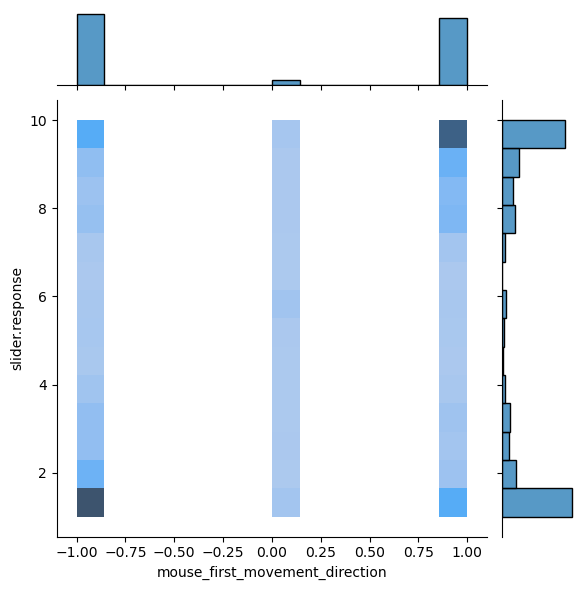

In [41]:
sns.jointplot(data=extdf, x="mouse_first_movement_direction", y="slider.response", kind="hist")

<Axes: xlabel='ambiguity', ylabel='mouse_first_movement_velocity'>

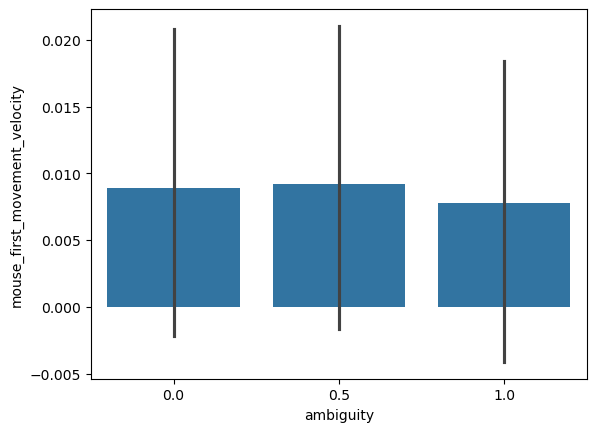

In [59]:
sns.barplot(data=extdf, x="ambiguity", y="mouse_first_movement_velocity")

<Axes: xlabel='mouse_first_movement_velocity', ylabel='slider.response'>

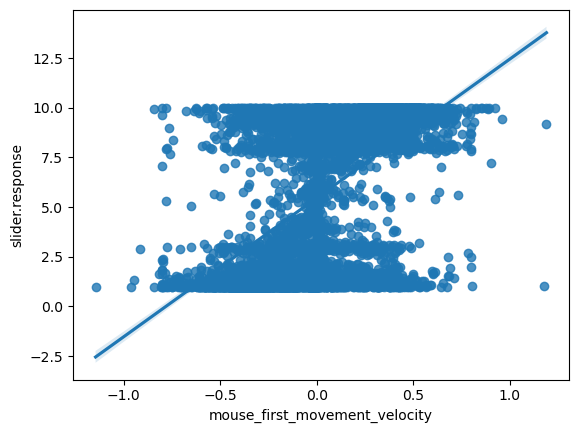

In [ ]:
sns.regplot(data=extdf, x="mouse_first_movement_velocity", y="slider.response")#, kind="hist")

In [43]:
extdf["mouse_auc"] = extdf.apply(
    lambda row: area_under_curve(json.loads(row["mouse.x"]),
                                 np.array([0]), #json.loads(row["mouse.y"]),
                                 lr.predict([[row["slider.response"]]]),
                                 0), axis=1)
extdf["mouse_length"] = extdf["mouse.x"].apply(lambda xs: trajectory_length(np.array(json.loads(xs))))

/home/jgauthier/u/transformers/lib/python3.10/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/jgauthier/u/transformers/lib/python3.10/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/jgauthier/u/transformers/lib/python3.10/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/jgauthier/u/transformers/lib/python3.10/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/jgauthier/u/transformers/lib/python3.10/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home

In [44]:
extdf["mouse_max_curvature"] = extdf.apply(
    lambda row: np.max(curvature(json.loads(row["mouse.x"]), json.loads(row["mouse.y"]))), axis=1)
extdf["mouse_avg_curvature"] = extdf.apply(
    lambda row: np.max(curvature(json.loads(row["mouse.x"]), json.loads(row["mouse.y"]))), axis=1)

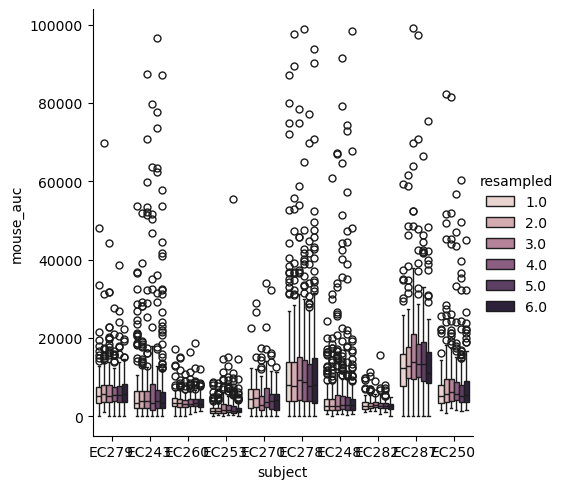

In [45]:
sns.catplot(data=extdf[extdf.mouse_auc < 1e5], x="subject", y="mouse_auc", hue="resampled", kind="box")

<Axes: xlabel='mouse_auc', ylabel='ambiguity'>

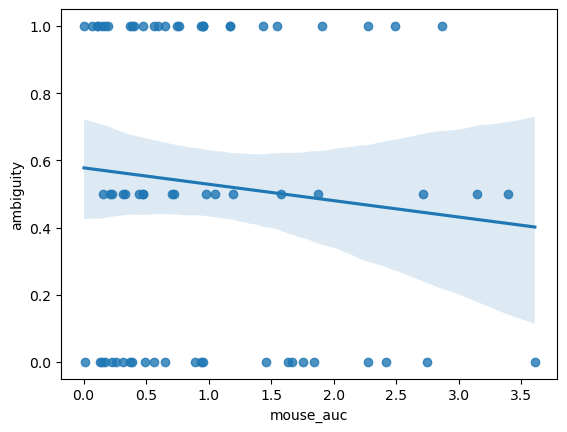

In [66]:
sns.regplot(data=extdf[extdf.mouse_auc < np.percentile(extdf.mouse_auc, 0.9)], x="mouse_auc", y="ambiguity")

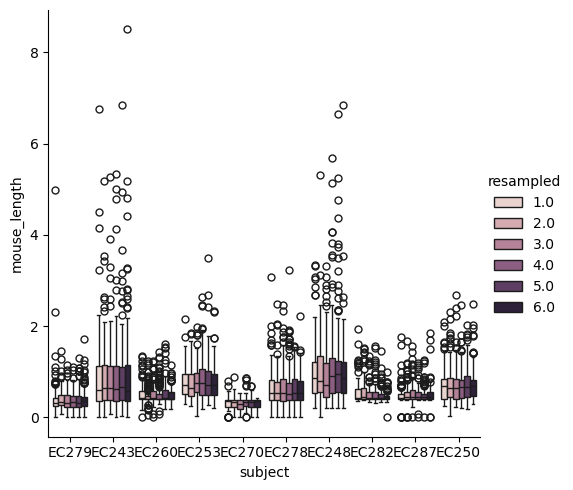

In [46]:
sns.catplot(data=extdf[extdf.mouse_length < 10], x="subject", y="mouse_length", hue="resampled", kind="box")

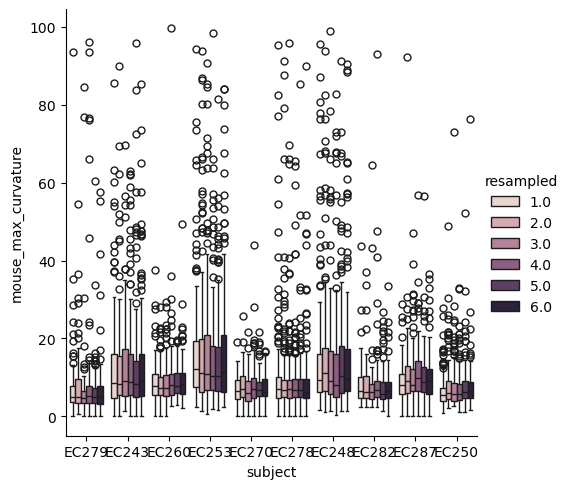

In [47]:
sns.catplot(data=extdf[extdf.mouse_max_curvature < 100], x="subject", y="mouse_max_curvature", hue="resampled", kind="box")

In [48]:
def plot_mouse_trajectories(complexity_measure="mouse_auc", points=(200,250,300,-100,-5)):
    study_trials = extdf.sort_values(complexity_measure).take(points).index
    for study_trial in study_trials:
        mouse_x, mouse_y, slider_response, compl = extdf.loc[study_trial][["mouse.x", "mouse.y", "slider.response", complexity_measure]]
        import json
        import matplotlib.pyplot as plt
        mouse_x = np.array(json.loads(mouse_x))
        mouse_y = np.array(json.loads(mouse_y))
        line, = plt.plot(mouse_x, mouse_y, alpha=0.5)
        # plt.quiver(mouse_x[:-1], mouse_y[:-1], mouse_x[1:] - mouse_x[:-1], mouse_y[1:] - mouse_y[:-1], scale_units='xy', angles='xy', scale=1)
        plt.plot(lr.predict([[slider_response]]), 0.005, color=line.get_color(), marker="o", label=f"measure={compl:.2f}")
    plt.legend(title=complexity_measure)

/home/jgauthier/u/transformers/lib/python3.10/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/jgauthier/u/transformers/lib/python3.10/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/jgauthier/u/transformers/lib/python3.10/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/jgauthier/u/transformers/lib/python3.10/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/jgauthier/u/transformers/lib/python3.10/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


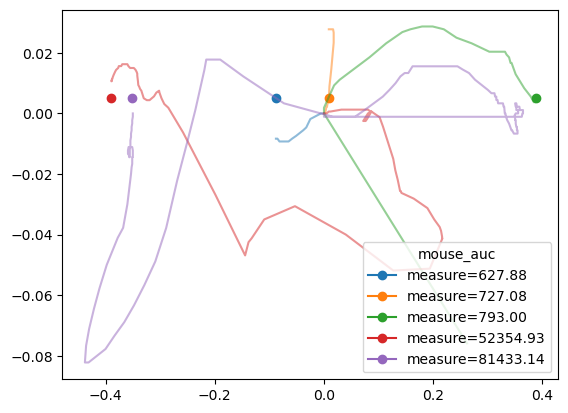

In [60]:
plot_mouse_trajectories("mouse_auc", points=(200,250,300,-100,-50))

/home/jgauthier/u/transformers/lib/python3.10/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/jgauthier/u/transformers/lib/python3.10/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/jgauthier/u/transformers/lib/python3.10/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/jgauthier/u/transformers/lib/python3.10/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/jgauthier/u/transformers/lib/python3.10/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


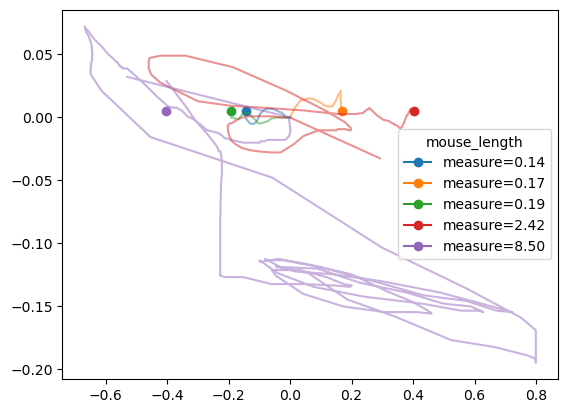

In [50]:
plot_mouse_trajectories("mouse_length")

/home/jgauthier/u/transformers/lib/python3.10/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/jgauthier/u/transformers/lib/python3.10/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


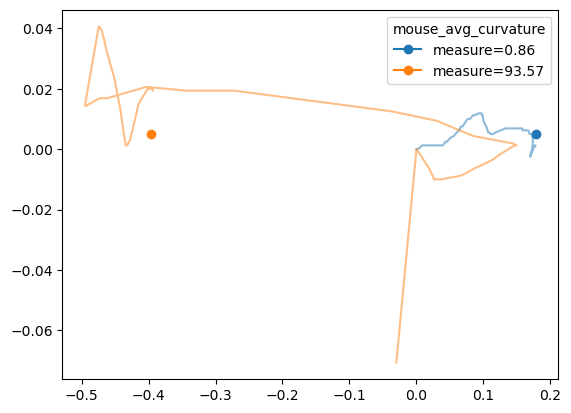

In [51]:
plot_mouse_trajectories("mouse_avg_curvature", [100, -100])

In [52]:
extdf.drop(columns=["mouse.x", "mouse.y", "mouse.leftButton", "mouse.rightButton", "mouse.midButton", "mouse.time"]).to_csv("extended_metadata.csv", index=False)